# Compare optimised pipeline runs (CSV diagnostics)

This notebook helps you compare multiple `optimised_processing` runs by:
- locating one-row diagnostics CSVs (recursively)
- concatenating them into a single table
- computing a few derived metrics (e.g. clearing %)
- plotting comparisons across `run_tag` / settings

The pipeline writes these diagnostics from the legacy method:
- `*_summary.csv` (one row per run)
- `*_sr_scale_verify.csv` (one row per run; band percentile audit)

If nothing is found, update `SEARCH_ROOTS` in Cell 2 to point at your run work directory.

# Terminal run prompts (EASI)

Copy/paste reference for running the NDVI build and three EDS A/B variants.

## Common variables (set once)

```bash
export EASI_REPO="/home/jovyan/work-easi-eds"
export EDS_BUCKET="dcceew-eds-data"
export EDS_PREFIX="AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds"

export NDVI_WORK="/home/jovyan/scratch/eds-work-optimised"
export EDS_WORK="/home/jovyan/scratch/eds-work-processing"

cd "$EASI_REPO"
```

## 1) Build NDVI products (required once per tile/date)

```bash
python "$EASI_REPO/scripts/easi-scripts/optimised_ndvi/scripts/ndvi_master_pipeline.py" \
  --tile p089r080 \
  --s3-bucket "$EDS_BUCKET" \
  --s3-prefix "$EDS_PREFIX" \
  --work-dir "$NDVI_WORK" \
  --cloud-max 40 \
  --start-date 2025-06-07 \
  --end-date 2026-01-09
```

## 2) Run EDS optimised processing (3 A/B variants)

All variants below write run-scoped outputs via `--run-id` and emit diagnostics CSVs via `--diagnostics`.

### Variant A: FORCE no SR scaling (debug baseline)

```bash
python "$EASI_REPO/scripts/easi-scripts/optimised_processing/scripts/eds_master_pipeline_optimised.py" \
  --tile p089r080 \
  --start-date 2025-06-07 \
  --end-date 2026-01-09 \
  --s3-bucket "$EDS_BUCKET" \
  --s3-prefix "$EDS_PREFIX" \
  --work-dir "$EDS_WORK" \
  --cloud-max 40 \
  --lookback 10 \
  --copy-to-home \
  --verbose \
  --diagnostics \
  --dlj-troubleshoot \
  --legacy-no-auto-sr-scale \
  --run-id run-no-auto-sr-scale
```

### Variant B: AUTO SR scaling (recommended default)

```bash
python "$EASI_REPO/scripts/easi-scripts/optimised_processing/scripts/eds_master_pipeline_optimised.py" \
  --tile p089r080 \
  --start-date 2025-06-07 \
  --end-date 2026-01-09 \
  --s3-bucket "$EDS_BUCKET" \
  --s3-prefix "$EDS_PREFIX" \
  --work-dir "$EDS_WORK" \
  --cloud-max 40 \
  --lookback 10 \
  --copy-to-home \
  --verbose \
  --diagnostics \
  --dlj-troubleshoot \
  --run-id run-auto-scale
```

### Variant C: MANUAL SR scaling (force 10000)

```bash
python "$EASI_REPO/scripts/easi-scripts/optimised_processing/scripts/eds_master_pipeline_optimised.py" \
  --tile p089r080 \
  --start-date 2025-06-07 \
  --end-date 2026-01-09 \
  --s3-bucket "$EDS_BUCKET" \
  --s3-prefix "$EDS_PREFIX" \
  --work-dir "$EDS_WORK" \
  --cloud-max 40 \
  --lookback 10 \
  --copy-to-home \
  --verbose \
  --diagnostics \
  --dlj-troubleshoot \
  --legacy-sr-scale 10000 \
  --run-id run-forced-10000
```

Tip: you generally don’t need `--rebase` for A/B runs if you keep unique `--run-id` values.

## Optional Variant D: legacy baseline includes nodata zeros

This adds `--legacy-baseline-include-nodata`, which makes the legacy baseline stats include nodata zeros in baseline mean/std/slope.
Default (recommended) behavior ignores zeros (treats 0 as nodata).

```bash
python "$EASI_REPO/scripts/easi-scripts/optimised_processing/scripts/eds_master_pipeline_optimised.py" \
  --tile p089r080 \
  --start-date 2025-06-07 \
  --end-date 2026-01-09 \
  --s3-bucket "$EDS_BUCKET" \
  --s3-prefix "$EDS_PREFIX" \
  --work-dir "$EDS_WORK" \
  --cloud-max 40 \
  --lookback 10 \
  --copy-to-home \
  --verbose \
  --diagnostics \
  --dlj-troubleshoot \
  --legacy-baseline-include-nodata \
  --run-id run-baseline-include-nodata
```

In [ ]:
DATA_SOURCE = "local"   # "local" or "s3"

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import re

import pandas as pd

# --- Configure where to search ---
# This notebook is intended to be run on EASI (Linux/Jupyter).
# The diagnostics CSVs are written to a local run folder like:
#   <work-dir>/<tile>/<run_tag>/diagnostics/*_summary.csv
#
# If you don't know the exact work-dir, start by searching common locations.

def default_search_roots() -> list[Path]:
    candidates: list[Path] = []
    # EASI/Jupyter common locations
    for p in (
        Path.cwd().resolve(),
        Path('/home/jovyan'),
        Path('/home/jovyan/work'),
        Path('/home/jovyan/shared'),
        Path('/mnt'),
        Path('/data'),
    ):
        try:
            if p.exists():
                candidates.append(p)
        except Exception:
            pass

    # De-dupe, preserve order
    out: list[Path] = []
    seen: set[str] = set()
    for p in candidates:
        sp = str(p)
        if sp not in seen:
            out.append(p)
            seen.add(sp)
    return out


SEARCH_ROOTS = default_search_roots()

# File patterns we expect from the legacy diagnostics step
SUMMARY_GLOB = '**/*_summary.csv'
SR_VERIFY_GLOB = '**/*_sr_scale_verify.csv'

print('CWD:', Path.cwd().resolve())
print('Search roots:')
for r in SEARCH_ROOTS:
    print(' -', r)

CWD: /home/jovyan/work-easi-eds/notebooks/validation
Search roots:
 - /home/jovyan/work-easi-eds/notebooks/validation
 - /home/jovyan
 - /mnt


In [2]:
@dataclass(frozen=True)
class LocatedFile:
    path: Path
    run_tag: str | None
    tile_from_path: str | None
    diag_suffix: str | None


def _infer_run_tag_and_tile_from_path(p: Path) -> tuple[str | None, str | None]:
    # Typical layout: <work-dir>/<tile>/<run_tag>/diagnostics/<file.csv>
    parts = list(p.parts)
    try:
        i = parts.index('diagnostics')
    except ValueError:
        return None, None
    if i - 1 < 0:
        return None, None
    run_tag = parts[i - 1]
    tile = parts[i - 2] if i - 2 >= 0 else None
    # sanity check tile like p089r080
    if tile and not re.match(r'^p\d{3}r\d{3}$', tile, flags=re.IGNORECASE):
        tile = None
    return run_tag, tile.lower() if tile else None


def _infer_diag_suffix_from_filename(p: Path) -> str | None:
    # The legacy script writes names like:
    #   <diag_name_base>_<diag_suffix>_summary.csv
    # where diag_suffix is like:
    #   sr-auto-10000_base-nodataaware
    #   sr-manual-10000_base-legacy
    name = p.name
    if name.endswith('_summary.csv'):
        core = name[:-len('_summary.csv')]
    elif name.endswith('_sr_scale_verify.csv'):
        core = name[:-len('_sr_scale_verify.csv')]
    else:
        core = p.stem

    # Heuristic: suffix starts after last occurrence of '_vi-'
    # Example: ..._vi-ndvi_e32756_<suffix>
    m = re.search(r'(_vi-[^_]+_e\d+)_', core)
    if not m:
        return None
    return core[m.end():] or None


def find_csvs(roots: list[Path], pattern: str) -> list[LocatedFile]:
    found: list[LocatedFile] = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for p in root.glob(pattern):
            if not p.is_file():
                continue
            run_tag, tile_from_path = _infer_run_tag_and_tile_from_path(p)
            diag_suffix = _infer_diag_suffix_from_filename(p)
            found.append(LocatedFile(path=p, run_tag=run_tag, tile_from_path=tile_from_path, diag_suffix=diag_suffix))
    # de-dupe, stable sort
    uniq = {str(x.path): x for x in found}
    return sorted(uniq.values(), key=lambda x: str(x.path))


def read_one_row_csvs(files: list[LocatedFile]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for lf in files:
        try:
            df = pd.read_csv(lf.path)
        except Exception as e:
            print('[WARN] failed to read:', lf.path, '->', e)
            continue
        if df.shape[0] != 1:
            print('[WARN] expected 1 row but got', df.shape[0], 'for', lf.path)
        df = df.copy()
        df['source_path'] = str(lf.path)
        df['run_tag'] = lf.run_tag
        df['tile_from_path'] = lf.tile_from_path
        df['diag_suffix'] = lf.diag_suffix
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    # prefer tile from CSV, fall back to path
    if 'tile' not in out.columns:
        out['tile'] = out['tile_from_path']
    else:
        out['tile'] = out['tile'].fillna(out['tile_from_path'])
    return out

In [3]:
# Locate and load summary CSVs
summary_files = find_csvs(SEARCH_ROOTS, SUMMARY_GLOB)
print('Found summary CSVs:', len(summary_files))
if summary_files:
    print('First few:')
    for lf in summary_files[:5]:
        print(' -', lf.path)

df_summary = read_one_row_csvs(summary_files)
print('Summary table shape:', df_summary.shape)
df_summary.head(5)

Found summary CSVs: 91
First few:
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-auto-scale/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-auto-10000_base-nodataaware_summary.csv
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-baseline-include-nodata/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-auto-10000_base-legacy_summary.csv
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-forced-10000/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-manual-10000_base-nodataaware_summary.csv
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-no-auto-sr-scale/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-no-auto-1_base-nodataaware_summary.csv
 - /home/jovyan/scratch/eds-work-processing/p089r081/run-auto-scale/diagnostics/sl8olre_p089r081_d2025082620260125_vi-ndvi_e32756_sr-auto-10000_base-nodataaware_summary.csv
[WARN] expected 1 row but got 117 for /home/jovyan/work-easi-eds/notebooks/validatio

,scene,tile,platform,start_date,end_date,window_start,window_end,lookback,sr_scale_factor,sr_scale_source,...,p95,mean,max_val,area_ha,pct_gt_T1_15,pct_gt_T1_18,pct_gt_T1_21.8,pct_gt_T2_30,pct_gt_T2_35,pct_gt_T2_39.54
0,p089r079,p089r079,sl8,20250607.0,20260125.0,407.0,325.0,10.0,10000.0,auto,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,p089r079,p089r079,sl8,20250607.0,20260125.0,407.0,325.0,10.0,10000.0,auto,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,p089r079,p089r079,sl8,20250607.0,20260125.0,407.0,325.0,10.0,10000.0,manual,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,p089r079,p089r079,sl8,20250607.0,20260125.0,407.0,325.0,10.0,1.0,no-auto,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,p089r081,p089r081,sl8,20250826.0,20260125.0,626.0,325.0,10.0,10000.0,auto,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# If we found nothing, show a hint and stop early
if df_summary.empty:
    raise RuntimeError(
        'No *_summary.csv files found under SEARCH_ROOTS.\n'
        'On EASI, set SEARCH_ROOTS in Cell 2 to the pipeline work directory (the folder that contains <tile>/<run_tag>/diagnostics/).\n'
        'Example: SEARCH_ROOTS = [Path("/home/jovyan/<somewhere>")]'
    )

In [5]:
# Derive comparison-friendly columns (clearing %, etc.)
import numpy as np
import matplotlib.pyplot as plt

def _sum_cols(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    existing = [c for c in cols if c in df.columns]
    if not existing:
        return pd.Series([pd.NA] * len(df), index=df.index)
    return df[existing].fillna(0).sum(axis=1)

df = df_summary.copy()

# These are the main clearing classes used by the legacy method
clearing_classes = [34, 35, 36, 37, 38, 39]
clearing_cols = [f'dll_count_{c}' for c in clearing_classes]

df['dll_clearing_px'] = _sum_cols(df, clearing_cols)
df['dll_ndvi_only_px'] = df['dll_count_3'] if 'dll_count_3' in df.columns else pd.NA
df['dll_no_clearing_px'] = df['dll_count_10'] if 'dll_count_10' in df.columns else pd.NA

if 'dll_total_px' in df.columns:
    df['dll_clearing_pct'] = (df['dll_clearing_px'] / df['dll_total_px']) * 100.0
else:
    df['dll_clearing_pct'] = pd.NA

# Helpful label for charts
df['run_label'] = (df.get('run_tag', pd.Series([''] * len(df))).fillna('') + ' | ' + df.get('diag_suffix', pd.Series([''] * len(df))).fillna('')).str.strip(' |')

# Sort for readability
sort_cols = [c for c in ['tile', 'end_date', 'run_tag', 'sr_scale_source', 'sr_scale_factor', 'baseline_include_nodata'] if c in df.columns]
if sort_cols:
    df = df.sort_values(sort_cols)

display_cols = [c for c in [
    'tile', 'run_tag', 'diag_suffix', 'start_date', 'end_date',
    'sr_scale_source', 'sr_scale_factor', 'baseline_include_nodata',
    'dll_total_px', 'dll_clearing_px', 'dll_clearing_pct',
    'ndviDiffStdErr_pct_ge_2_5', 'ndviDiffStdErr_pct_ge_6_0', 'ndviDiffStdErr_pct_ge_10_0',
    'source_path',
] if c in df.columns]

df[display_cols].head(25)

,tile,run_tag,diag_suffix,start_date,end_date,sr_scale_source,sr_scale_factor,baseline_include_nodata,dll_total_px,dll_clearing_px,dll_clearing_pct,ndviDiffStdErr_pct_ge_2_5,ndviDiffStdErr_pct_ge_6_0,ndviDiffStdErr_pct_ge_10_0,source_path
0,p089r079,run-auto-scale,sr-auto-10000_base-nodataaware,20250607.0,20260125.0,auto,10000.0,False,53842248.0,6140656.0,11.404903,30.099120,13.078002,4.733257,/home/jovyan/scratch/eds-work-processing/p089r...
1,p089r079,run-baseline-include-nodata,sr-auto-10000_base-legacy,20250607.0,20260125.0,auto,10000.0,True,53842248.0,1744806.0,3.240589,8.489968,3.908478,1.462809,/home/jovyan/scratch/eds-work-processing/p089r...
2,p089r079,run-forced-10000,sr-manual-10000_base-nodataaware,20250607.0,20260125.0,manual,10000.0,False,53842248.0,6140656.0,11.404903,30.099120,13.078002,4.733257,/home/jovyan/scratch/eds-work-processing/p089r...
3,p089r079,run-no-auto-sr-scale,sr-no-auto-1_base-nodataaware,20250607.0,20260125.0,no-auto,1.0,False,53842248.0,12072067.0,22.421179,30.099120,13.078002,4.733257,/home/jovyan/scratch/eds-work-processing/p089r...
4,p089r081,run-auto-scale,sr-auto-10000_base-nodataaware,20250826.0,20260125.0,auto,10000.0,False,54355136.0,7542029.0,13.875467,26.659186,11.086744,3.968989,/home/jovyan/scratch/eds-work-processing/p089r...
5,p089r081,run-baseline-include-nodata,sr-auto-10000_base-legacy,20250826.0,20260125.0,auto,10000.0,True,54355136.0,2237426.0,4.116310,6.036665,1.548403,0.500819,/home/jovyan/scratch/eds-work-processing/p089r...
6,p089r081,run-forced-10000,sr-manual-10000_base-nodataaware,20250826.0,20260125.0,manual,10000.0,False,54355136.0,7542029.0,13.875467,26.659186,11.086744,3.968989,/home/jovyan/scratch/eds-work-processing/p089r...
7,p089r081,run-no-auto-sr-scale,sr-no-auto-1_base-nodataaware,20250826.0,20260125.0,no-auto,1.0,False,54355136.0,15580435.0,28.664145,26.659186,11.086744,3.968989,/home/jovyan/scratch/eds-work-processing/p089r...
8,p089r082,run-auto-scale,sr-auto-10000_base-nodataaware,20250826.0,20260125.0,auto,10000.0,False,54763722.0,4030508.0,7.359814,25.260066,11.020380,4.241901,/home/jovyan/scratch/eds-work-processing/p089r...
9,p089r082,run-baseline-include-nodata,sr-auto-10000_base-legacy,20250826.0,20260125.0,auto,10000.0,True,54763722.0,1109269.0,2.025554,4.603530,1.928567,1.032495,/home/jovyan/scratch/eds-work-processing/p089r...


### Interpretation of DLL clearing percentage by run

These plots compare the percentage of pixels classified as clearing (`DLL` classes 34–39) for multiple processing configurations across different Landsat tiles.

Each subplot represents a separate tile, while each bar represents a different workflow configuration combining:
- surface reflectance (SR) scaling behaviour, and
- baseline nodata handling.

The runs include:
- `sr-no-auto-1`: no SR scaling applied,
- `sr-manual-10000`: manually forcing SR scaling by 10000,
- `sr-auto-10000`: automatic SR scaling detection,
- `base-nodataaware`: nodata values excluded from baseline statistics,
- `base-legacy`: legacy behaviour where nodata zeros are included in the baseline.

Overall, the plots demonstrate that SR scaling has a major influence on clearing detection results.

Runs without SR scaling generally produce substantially larger clearing percentages, indicating that unscaled reflectance values inflate the spectral metrics and lead to excessive clearing detection. In contrast, runs using either automatic or manually forced scaling by 10000 produce more moderate and stable outputs.

The comparison between `sr-manual-10000` and `sr-auto-10000` shows very similar clearing percentages, suggesting that the automatic scaling detection is functioning correctly.

The `base-legacy` runs typically produce lower clearing percentages than the nodata-aware runs. This occurs because including nodata zeros in the historical baseline artificially increases baseline variability and suppresses anomaly detection, causing the workflow to under-detect clearing.

Differences between tiles indicate that landscape characteristics, vegetation structure, and seasonal conditions also influence clearing estimates. However, the plots clearly show that preprocessing decisions, particularly SR scaling and nodata handling, are major controls on workflow behaviour and output stability.

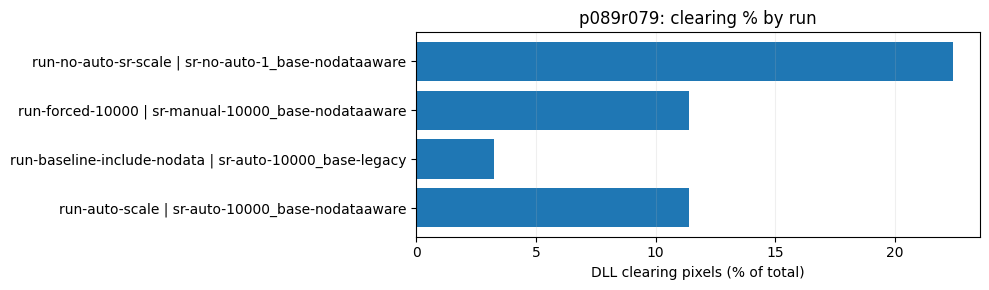

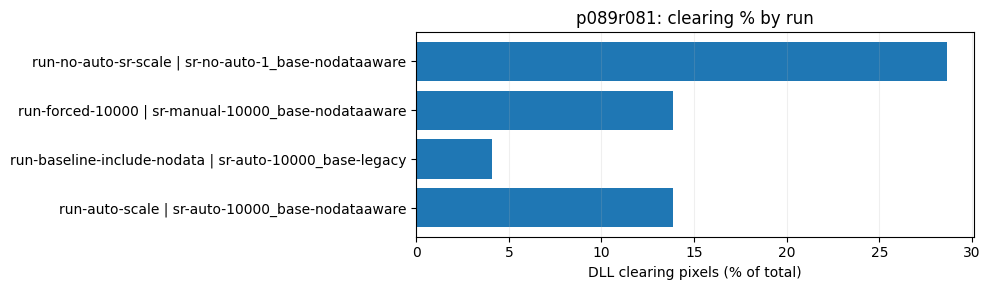

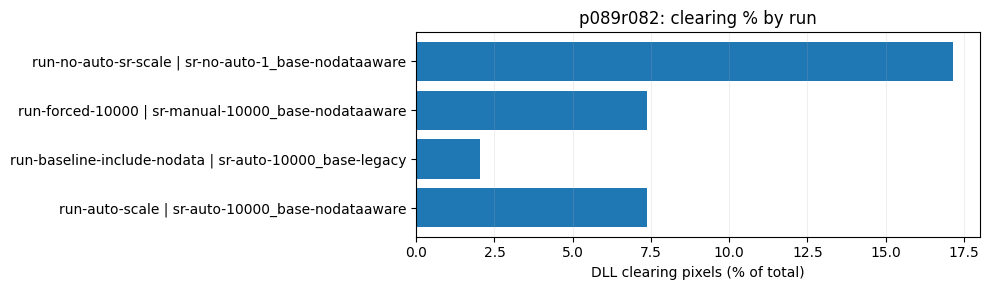

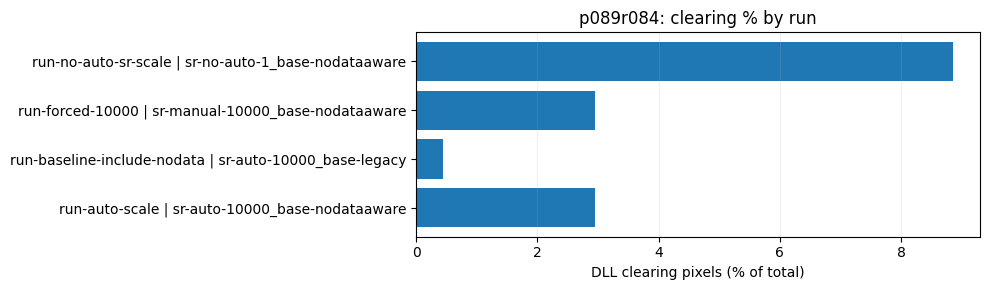

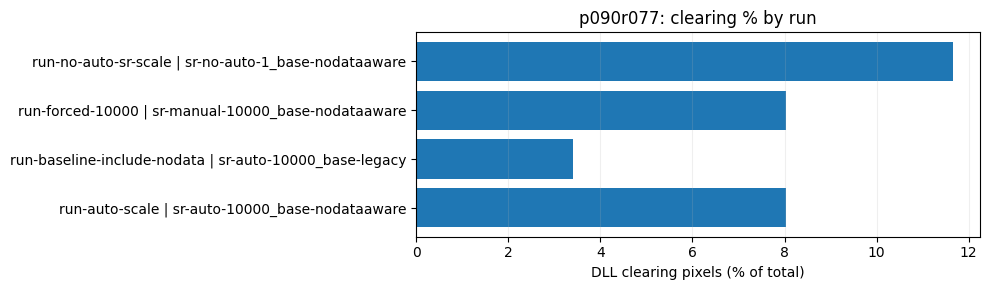

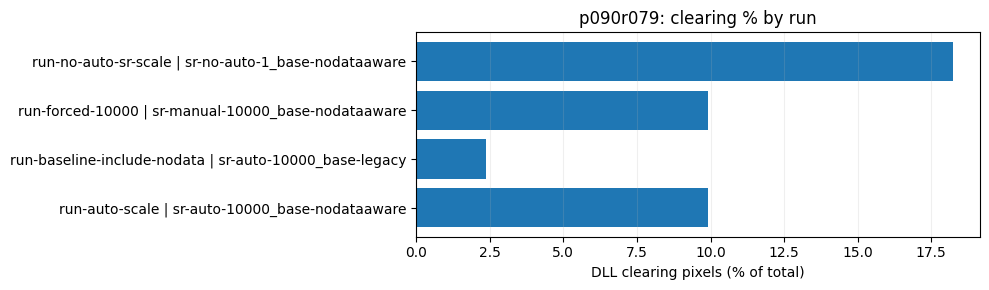

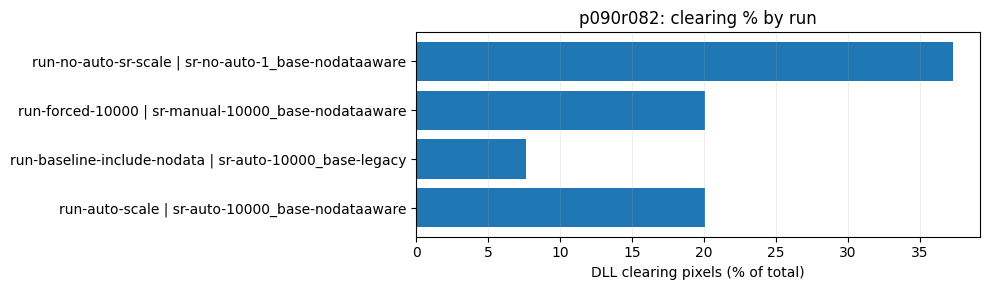

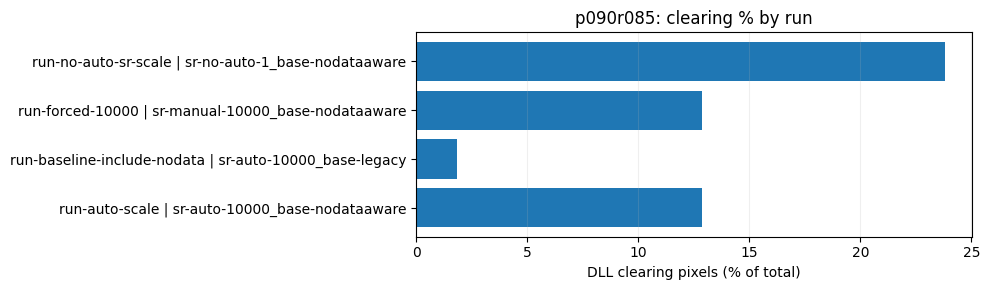

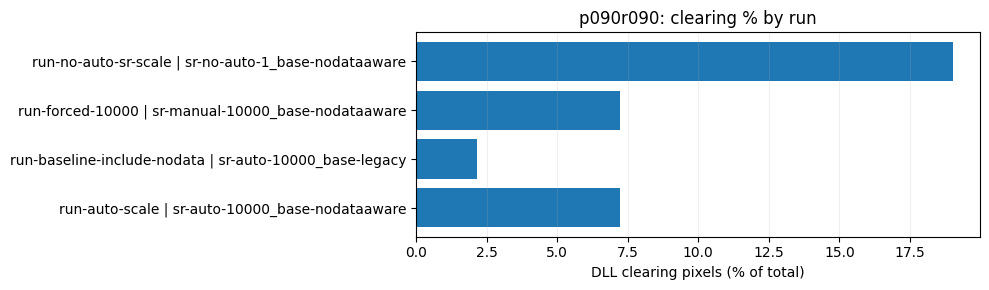

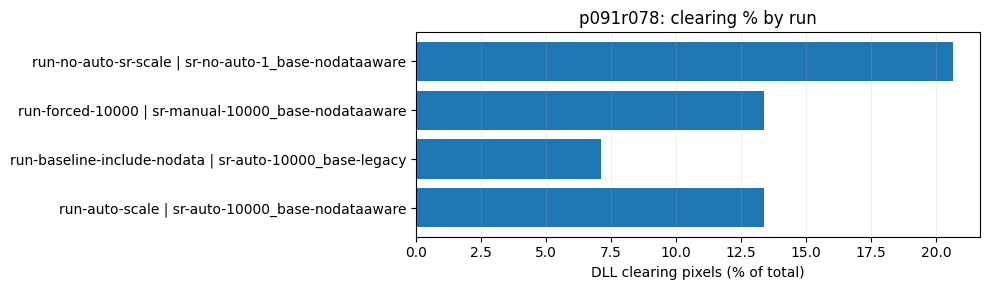

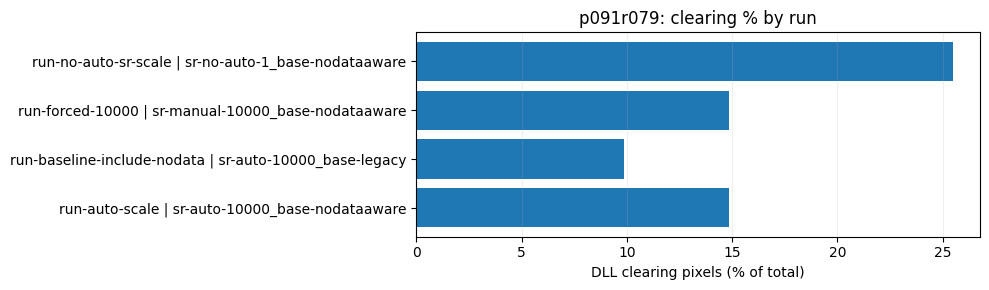

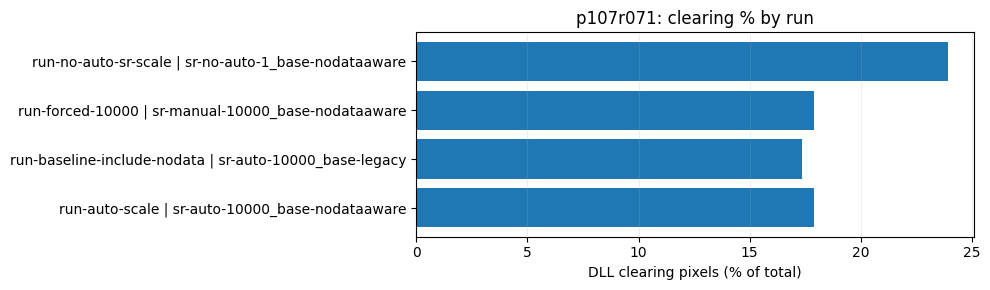

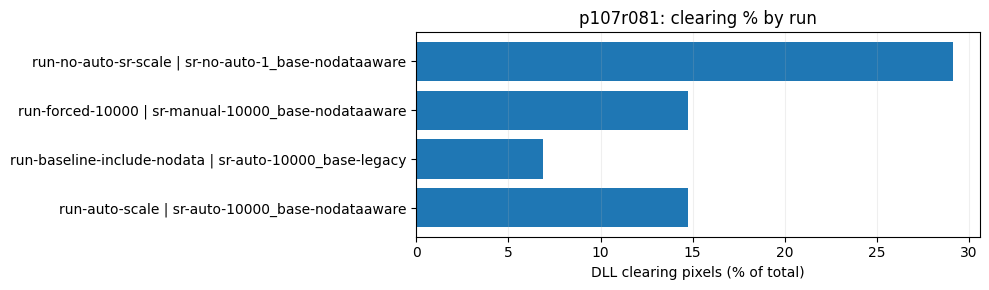

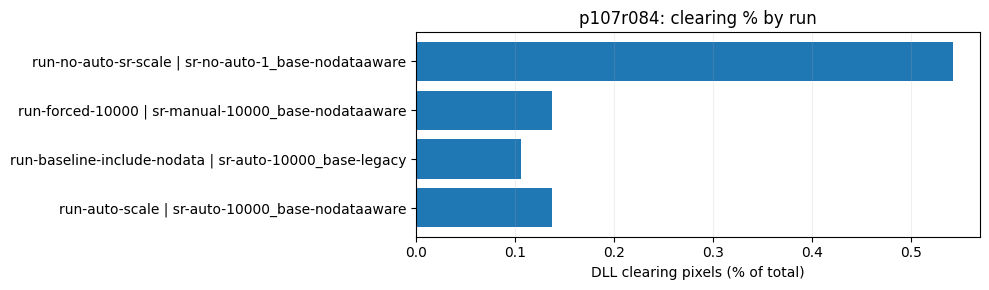

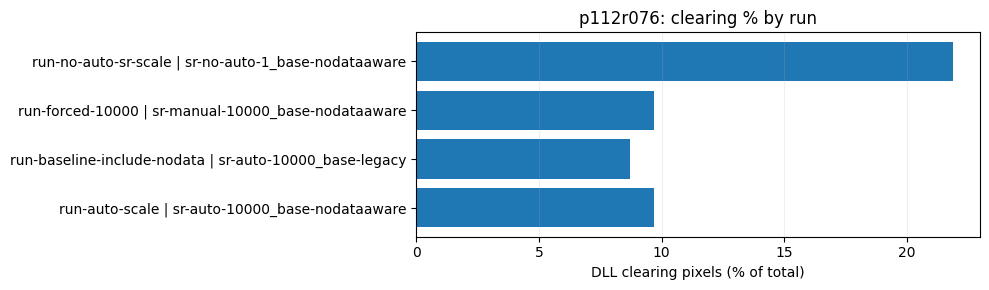

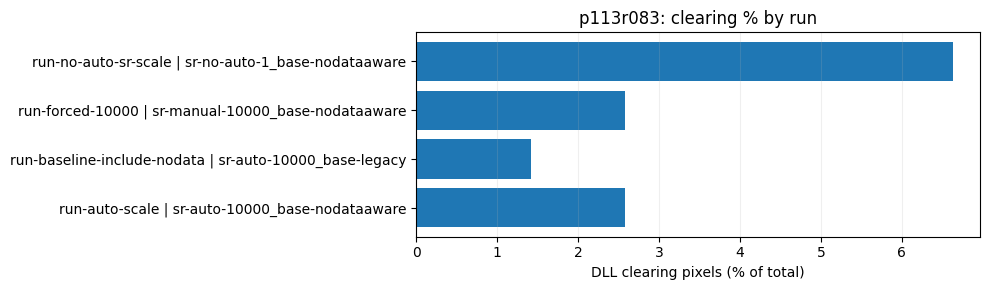

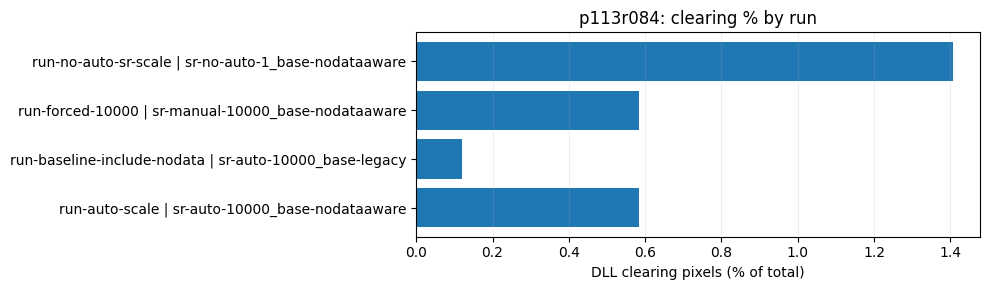

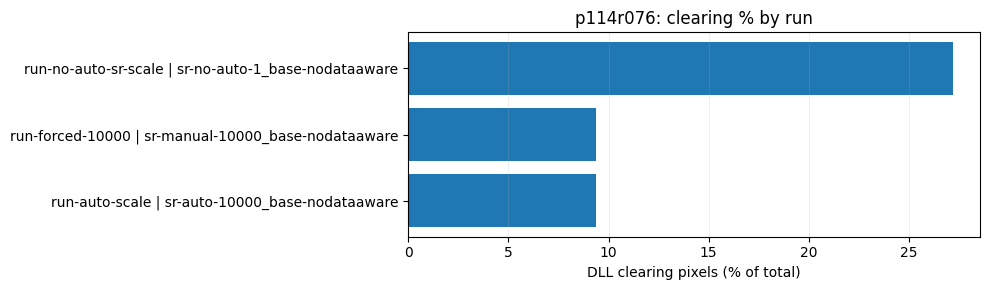

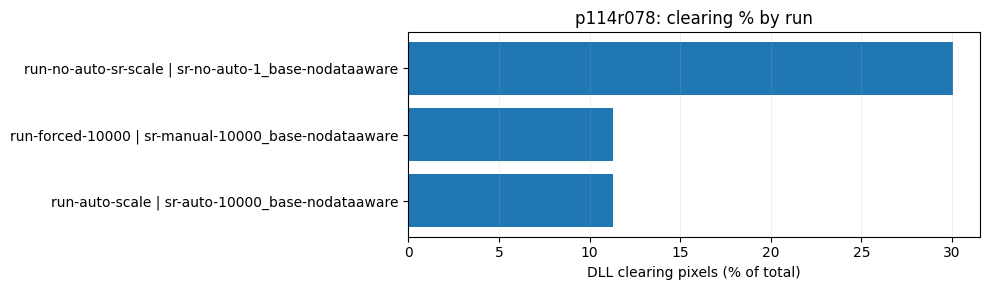

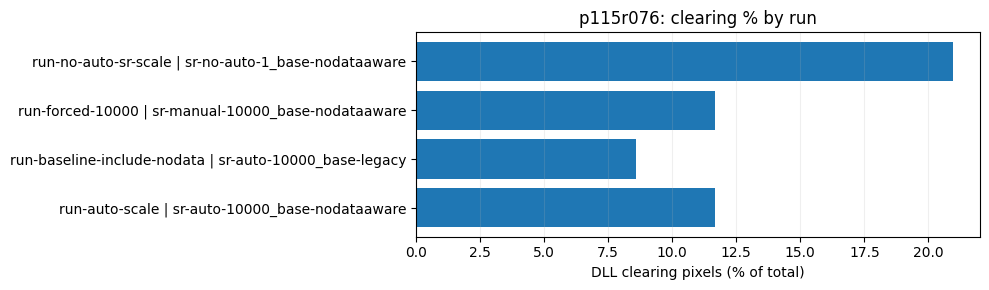

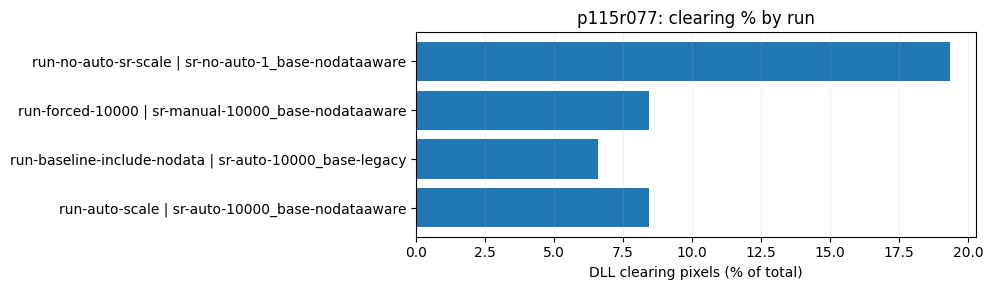

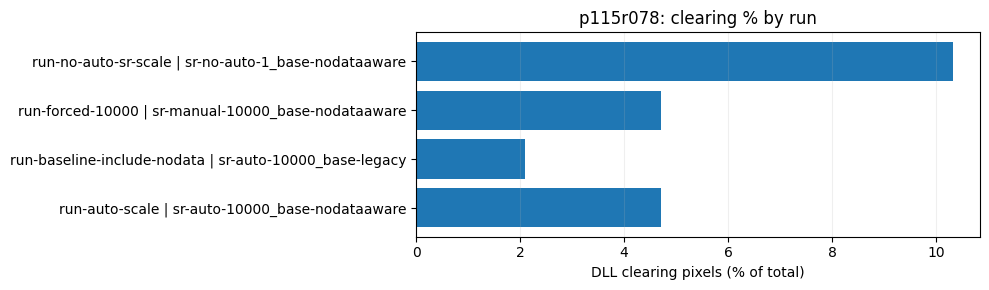

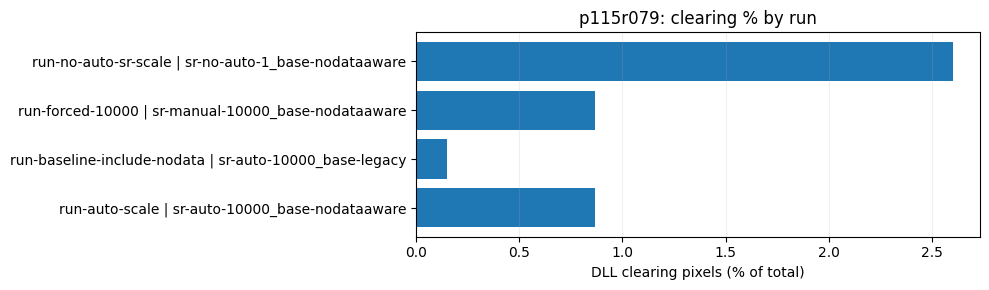

In [6]:
# Plot 1: clearing % by run (one chart per tile)
def plot_clearing_by_tile(df: pd.DataFrame) -> None:
    if 'dll_clearing_pct' not in df.columns:
        print('[WARN] dll_clearing_pct not present; cannot plot.')
        return

    tiles = [t for t in sorted(df['tile'].dropna().unique())]
    if not tiles:
        print('[WARN] No tiles found to plot.')
        return

    for tile in tiles:
        sub = df[df['tile'] == tile].copy()
        sub = sub.dropna(subset=['dll_clearing_pct'])
        if sub.empty:
            continue
        sub = sub.sort_values(['run_tag', 'diag_suffix'], na_position='last')

        plt.figure(figsize=(10, max(3, 0.35 * len(sub))))
        y = np.arange(len(sub))
        plt.barh(y, sub['dll_clearing_pct'].astype(float))
        plt.yticks(y, sub['run_label'])
        plt.xlabel('DLL clearing pixels (% of total)')
        plt.title(f'{tile}: clearing % by run')
        plt.grid(axis='x', alpha=0.2)
        plt.tight_layout()
        plt.show()

plot_clearing_by_tile(df)

### Interpretation of clearing pixels vs SR scaling factor

This plot compares the number of pixels classified as clearing (`DLL` classes 34–39) against the surface reflectance (SR) scaling factor used in each run.

- Each point represents one processing run for a tile/date combination.
- The x-axis shows the SR scaling factor applied to the reflectance data.
- The y-axis shows the total number of pixels classified as clearing.

Two distinct groups are visible:

- **Scale factor near 0 or no scaling**: these runs generally produced much larger and more variable clearing outputs.
- **Scale factor = 10000**: these runs produced lower and more stable clearing outputs.

This indicates that the change detection workflow is highly sensitive to SR scaling. Without scaling, the spectral calculations operate on excessively large reflectance values (e.g. 0–10000 instead of 0–1), which inflates the spectral index and causes the algorithm to over-detect clearing.

Applying the expected SR scaling factor of 10000 stabilises the spectral metrics and reduces likely false positives, resulting in more physically realistic clearing estimates.

The spread of values within each group also shows that tile characteristics and seasonal conditions still influence the amount of detected clearing, but SR scaling is one of the dominant controls on output behaviour.

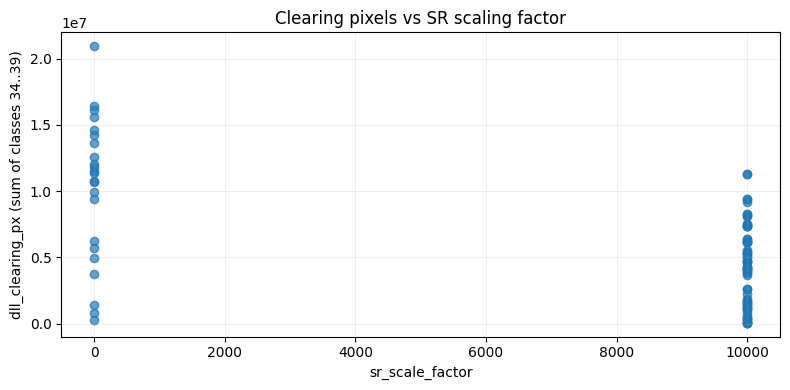

In [7]:
# Plot 2: clearing pixels vs SR scaling factor (quick correlation check)
if 'dll_clearing_px' in df.columns and 'sr_scale_factor' in df.columns:
    plt.figure(figsize=(8, 4))
    plt.scatter(df['sr_scale_factor'].astype(float), df['dll_clearing_px'].astype(float), alpha=0.7)
    plt.xlabel('sr_scale_factor')
    plt.ylabel('dll_clearing_px (sum of classes 34..39)')
    plt.title('Clearing pixels vs SR scaling factor')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('[INFO] Missing columns for SR scale scatter plot')

In [8]:
# Load SR scaling verification CSVs (optional)
sr_files = find_csvs(SEARCH_ROOTS, SR_VERIFY_GLOB)
print('Found SR verify CSVs:', len(sr_files))
if sr_files:
    print('First few:')
    for lf in sr_files[:5]:
        print(' -', lf.path)

df_sr = read_one_row_csvs(sr_files)
print('SR verify table shape:', df_sr.shape)
df_sr.head(3)

Found SR verify CSVs: 90
First few:
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-auto-scale/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-auto-10000_base-nodataaware_sr_scale_verify.csv
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-baseline-include-nodata/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-auto-10000_base-legacy_sr_scale_verify.csv
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-forced-10000/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-manual-10000_base-nodataaware_sr_scale_verify.csv
 - /home/jovyan/scratch/eds-work-processing/p089r079/run-no-auto-sr-scale/diagnostics/sl8olre_p089r079_d2025060720260125_vi-ndvi_e32756_sr-no-auto-1_base-nodataaware_sr_scale_verify.csv
 - /home/jovyan/scratch/eds-work-processing/p089r081/run-auto-scale/diagnostics/sl8olre_p089r081_d2025082620260125_vi-ndvi_e32756_sr-auto-10000_base-nodataaware_sr_scale_verify.csv
SR verify table shape: (90, 172)


,scene,tile,platform,start_date,end_date,sr_scale_factor,sr_scale_source,baseline_include_nodata,start_b2_raw_count,start_b2_raw_mean,...,end_b6_scaled_p01,end_b6_scaled_p05,end_b6_scaled_p50,end_b6_scaled_p95,end_b6_scaled_p99,end_b6_scaled_max,source_path,run_tag,tile_from_path,diag_suffix
0,p089r079,p089r079,sl8,20250607,20260125,10000.0,auto,False,19884394,470.580868,...,0.0293,0.0363,0.0791,0.1786,0.2476,1.0,/home/jovyan/scratch/eds-work-processing/p089r...,run-auto-scale,p089r079,sr-auto-10000_base-nodataaware
1,p089r079,p089r079,sl8,20250607,20260125,10000.0,auto,True,19884394,470.580868,...,0.0293,0.0363,0.0791,0.1786,0.2476,1.0,/home/jovyan/scratch/eds-work-processing/p089r...,run-baseline-include-nodata,p089r079,sr-auto-10000_base-legacy
2,p089r079,p089r079,sl8,20250607,20260125,10000.0,manual,False,19884394,470.580868,...,0.0293,0.0363,0.0791,0.1786,0.2476,1.0,/home/jovyan/scratch/eds-work-processing/p089r...,run-forced-10000,p089r079,sr-manual-10000_base-nodataaware


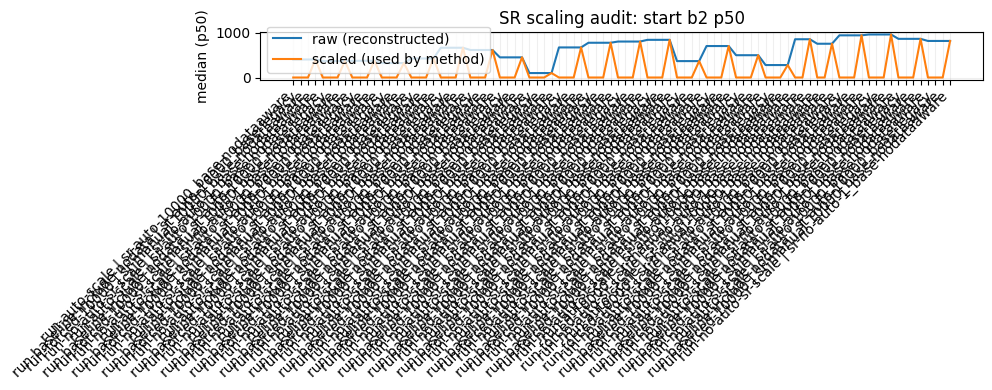

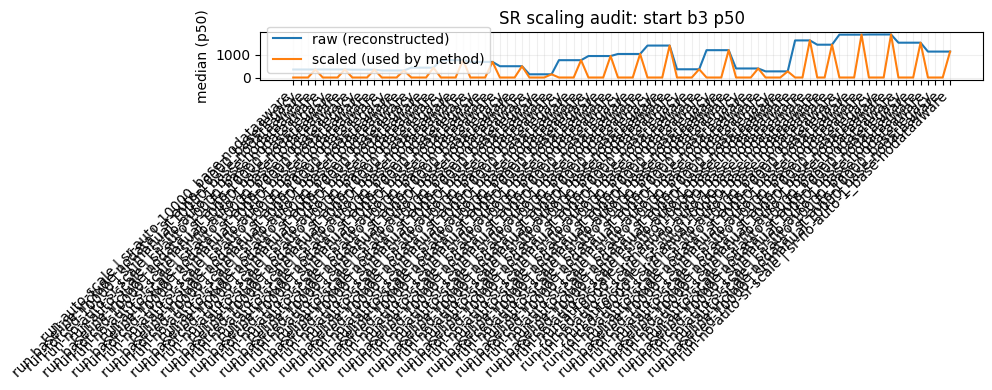

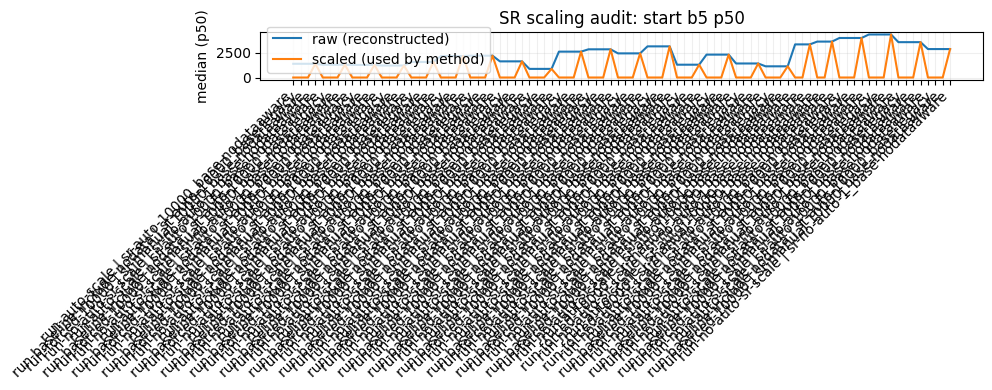

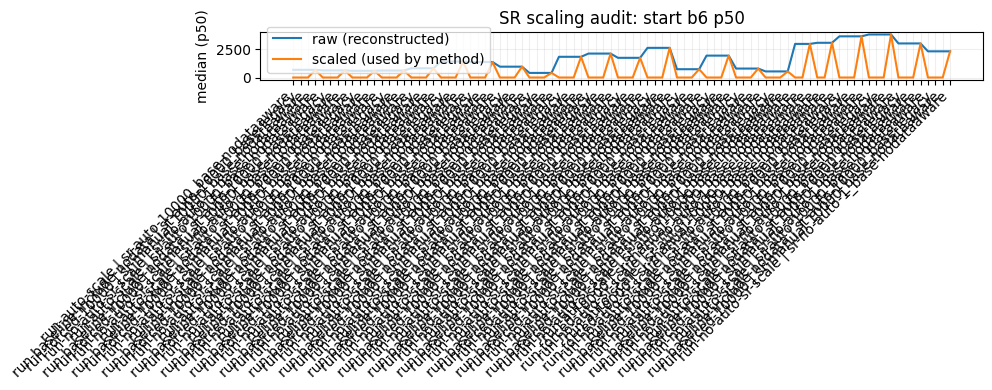

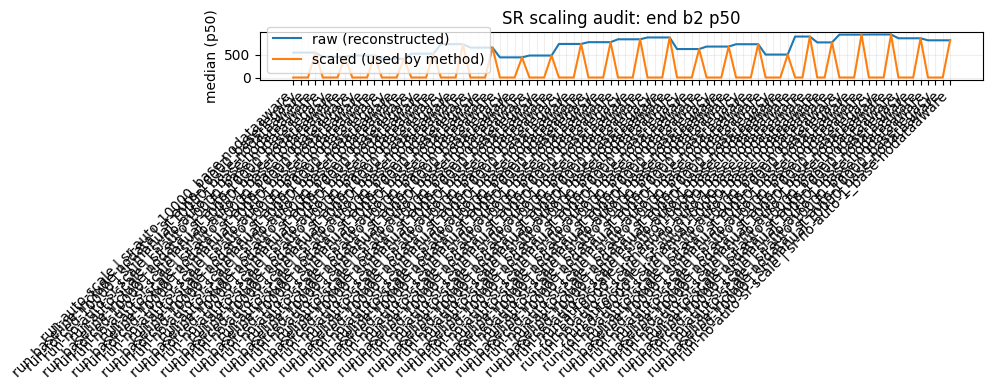

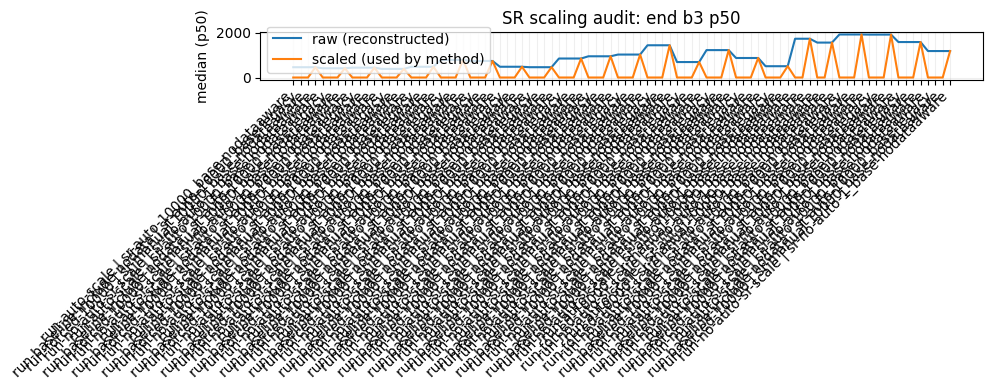

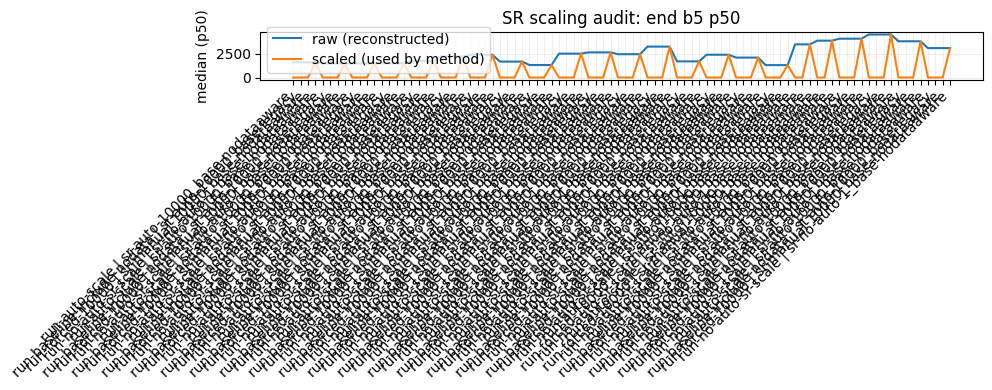

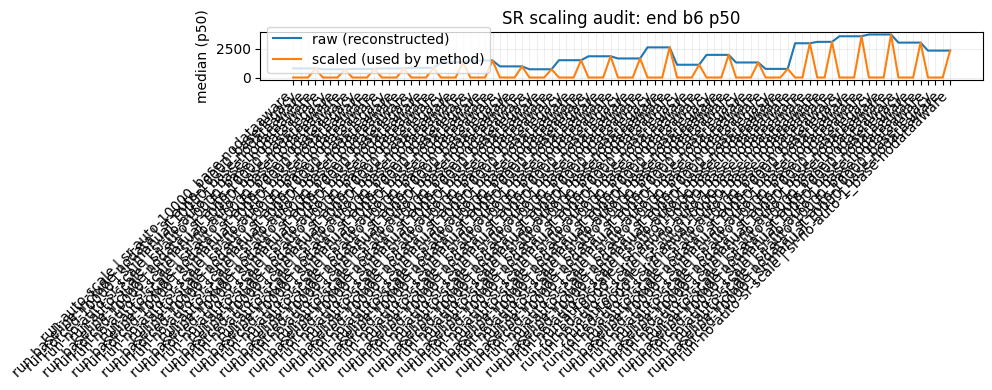

In [9]:
# SR scaling audit plot: raw vs scaled median (p50) for start/end bands
def _maybe_col(df: pd.DataFrame, col: str) -> bool:
    return col in df.columns and df[col].notna().any()

if df_sr.empty:
    print('[INFO] No sr_scale_verify CSVs found (this is optional).')
else:
    dfp = df_sr.copy()
    dfp['run_label'] = (dfp.get('run_tag', pd.Series([''] * len(dfp))).fillna('') + ' | ' + dfp.get('diag_suffix', pd.Series([''] * len(dfp))).fillna('')).str.strip(' |')
    # Expect columns like: start_b2_raw_p50 / start_b2_scaled_p50
    targets = []
    for which in ['start', 'end']:
        for band in ['b2', 'b3', 'b5', 'b6']:
            raw = f'{which}_{band}_raw_p50'
            scaled = f'{which}_{band}_scaled_p50'
            if _maybe_col(dfp, raw) and _maybe_col(dfp, scaled):
                targets.append((which, band, raw, scaled))

    if not targets:
        print('[INFO] No p50 columns found to plot in SR verify table.')
    else:
        for which, band, raw_col, scaled_col in targets:
            plt.figure(figsize=(10, 4))
            x = np.arange(len(dfp))
            plt.plot(x, dfp[raw_col].astype(float), label='raw (reconstructed)')
            plt.plot(x, dfp[scaled_col].astype(float), label='scaled (used by method)')
            plt.xticks(x, dfp['run_label'], rotation=45, ha='right')
            plt.ylabel('median (p50)')
            plt.title(f'SR scaling audit: {which} {band} p50')
            plt.grid(alpha=0.2)
            plt.legend()
            plt.tight_layout()
            plt.show()

In [10]:
# Save concatenated tables for later use
out_dir = Path.cwd().resolve() / 'outputs' / 'diagnostics_concat'
out_dir.mkdir(parents=True, exist_ok=True)

summary_out = out_dir / 'all_runs_summary_concat.csv'
df.to_csv(summary_out, index=False)
print('Wrote:', summary_out)

if not df_sr.empty:
    sr_out = out_dir / 'all_runs_sr_scale_verify_concat.csv'
    df_sr.to_csv(sr_out, index=False)
    print('Wrote:', sr_out)

Wrote: /home/jovyan/work-easi-eds/notebooks/validation/outputs/diagnostics_concat/all_runs_summary_concat.csv
Wrote: /home/jovyan/work-easi-eds/notebooks/validation/outputs/diagnostics_concat/all_runs_sr_scale_verify_concat.csv
